In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from GTSRB_utils import GTSRB_CLASSES, predict_traffic_sign, create_subset_loader, load_ppm_image


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("TrafficSigns_EfficientNetB1.keras")

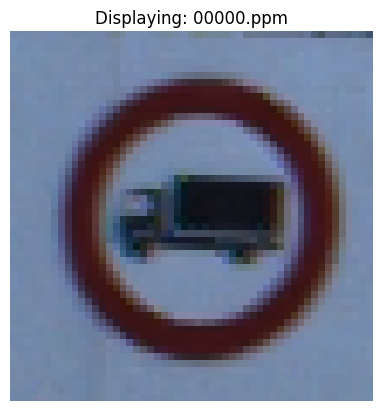

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

def display_ppm_image(file_path):
    """
    Display a .ppm image using Pillow and Matplotlib.

    Parameters:
    -----------
    file_path : str
        Path to the .ppm image file.
    """
    # Open the .ppm file
    with Image.open(file_path) as img:
        # Convert to a format Matplotlib can handle (e.g., RGB)
        #img_rgb = img.convert("RGB")

        # Display using matplotlib
        plt.imshow(img)
        plt.axis('off')  # Hide axis for cleaner display
        plt.title(f"Displaying: {file_path}")
        plt.show()

# Example usage:
display_ppm_image("00000.ppm")


In [21]:
import tensorflow as tf
from PIL import Image
import numpy as np



image_path = "00000.ppm"
# Load and preprocess the image with the correct target size (240x240)
image = load_ppm_image(image_path, target_size=(240, 240))
# Call your prediction function with the image, model, and class mapping
predict_traffic_sign(image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
Prediction shape: (1, 43)
Predicted class: Vehicles over 3.5 tons prohibited


np.int64(16)

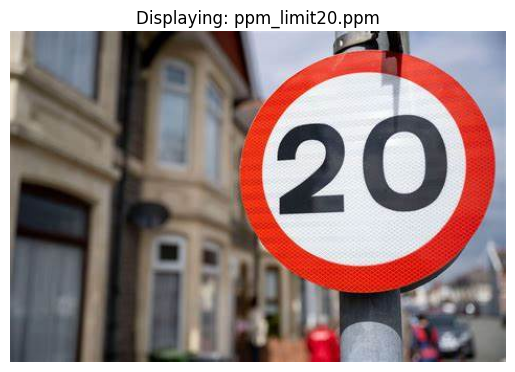

In [22]:
from PIL import Image

def convert_jfif_to_ppm(input_path, output_path):
    """
    Convert a .jfif (JPEG) file to a .ppm file using Pillow.

    Parameters:
    -----------
    input_path : str
        Path to the input .jfif file.
    output_path : str
        Path to the output .ppm file.
    """
    # Open the JFIF image
    with Image.open(input_path) as img:
        # Convert to RGB (PPM is typically an RGB format)
        img_rgb = img.convert("RGB")
        # Save as PPM
        img_rgb.save(output_path, format="PPM")

# Example usage:
convert_jfif_to_ppm("Limit20.jfif", "ppm_limit20.ppm")
new_photo="ppm_limit20.ppm"
display_ppm_image(new_photo)

In [ ]:
from PIL import Image

with Image.open("00001.ppm") as img:
    print("Image size:", img.size)  # (width, height)

Image size: (42, 45)


In [23]:
# Load and preprocess the image with the correct target size (240x240)
limit20image = load_ppm_image(new_photo, target_size=(240, 240))
# Call your prediction function with the image, model, and class mapping
predict_traffic_sign(limit20image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Predicted class: Speed limit 20


np.int64(0)

In [ ]:
from PIL import Image
import numpy as np
import tensorflow as tf

def ppm_to_tensor_tf(file_path):
    """
    Load a .ppm file and convert it to a TensorFlow tensor.
    Returns a 4D tensor of shape (1, height, width, 3).
    """
    with Image.open(file_path) as img:
        # Convert the image to RGB (just in case it's not already)
        img_rgb = img.convert("RGB")

        # Convert the PIL image to a NumPy array
        img_np = np.array(img_rgb)

        # Convert the NumPy array to a TF tensor
        # Shape: (height, width, channels)
        img_tensor = tf.convert_to_tensor(img_np, dtype=tf.float32)

        # Optionally, add a batch dimension at the start
        img_tensor = tf.expand_dims(img_tensor, axis=0)  # shape -> (1, H, W, 3)

    return img_tensor

# Usage:
tensored_image = ppm_to_tensor_tf("00001.ppm")
print(tensored_image.shape)  # e.g., (1, 224, 224, 3)


(1, 45, 42, 3)


In essence, this first paragraph of Section 2 sets the stage for understanding adversarial attacks by defining what it means for a machine learning model to be robust. It establishes the expectation that small, human-imperceptible changes to an input image should not lead to a different classification by the model. The formal definition of ρ-robustness provides a framework for quantifying and studying this property, highlighting that adversarial examples are perturbations within a certain bound (ρ) that cause a model to make an incorrect prediction, thus indicating a lack of robustness. This relates to our earlier discussions about the goal of adversarial attacks, which is to find such perturbations.

In [50]:
import numpy as np
import tensorflow as tf
from PIL import Image
from GTSRB_utils import GTSRB_CLASSES, load_ppm_image, predict_traffic_sign

def simba_attack(image_tensor, true_label, model, num_iters=2000, epsilon=20, print_every=10):
    """
    image_tensor: TensorFlow tensor of shape (1, H, W, 3) in [0, 255]
    true_label: Integer label (the true class of the image)
    model: TensorFlow/Keras model used for prediction
    num_iters: Maximum number of iterations (queries)
    epsilon: Perturbation magnitude for each pixel update
    print_every: Frequency (in iterations) at which to print detailed logs
    """
    # Convert image tensor to numpy array for manipulation
    adv = image_tensor.numpy()  # shape: (1, H, W, 3)
    H, W, C = adv.shape[1], adv.shape[2], adv.shape[3]
    n_dims = H * W * C

    # Generate a random permutation of pixel indices
    perm = np.random.permutation(n_dims)

    # Get the initial probability for the true class
    pred = model.predict(adv)
    true_prob = pred[0][true_label]
    print("Initial true class probability: {:.4f}".format(true_prob))

    # Loop over the maximum number of iterations
    for i in range(num_iters):
        # Wrap around the permutation if i >= n_dims
        idx = perm[i % n_dims]
        # Convert flat index to (row, col, channel)
        channel = idx % C
        temp = idx // C
        col = temp % W
        row = temp // W

        # Create a perturbation only at the selected pixel and channel
        perturb = np.zeros_like(adv)
        perturb[0, row, col, channel] = epsilon

        # Try positive perturbation
        adv_pos = np.clip(adv + perturb, 0, 255)
        prob_pos = model.predict(adv_pos)
        pos_true_prob = prob_pos[0][true_label]

        # ---- Check Final Image & Probability Changes (Note 4) ----
        diff_pos = pos_true_prob - true_prob

        # For an untargeted attack, we want to lower the confidence of the true class
        if pos_true_prob < true_prob:
            adv = adv_pos
            print(f"Iteration {i}: +epsilon -> pixel=({row},{col},{channel}), "
                  f"old_prob={true_prob:.6f}, new_prob={pos_true_prob:.6f}, diff={diff_pos:.6f}")
            true_prob = pos_true_prob
            continue

        # Try negative perturbation if positive did not help
        adv_neg = np.clip(adv - perturb, 0, 255)
        prob_neg = model.predict(adv_neg)
        neg_true_prob = prob_neg[0][true_label]

        # ---- Check Final Image & Probability Changes (Note 4) ----
        diff_neg = neg_true_prob - true_prob

        if neg_true_prob < true_prob:
            adv = adv_neg
            print(f"Iteration {i}: -epsilon -> pixel=({row},{col},{channel}), "
                  f"old_prob={true_prob:.6f}, new_prob={neg_true_prob:.6f}, diff={diff_neg:.6f}")
            true_prob = neg_true_prob
            continue

        # Optionally print status even if no update occurred
        if (i % print_every) == 0:
            print(f"Iteration {i}: No update at pixel=({row},{col},{channel}). "
                  f"pos_diff={diff_pos:.6f}, neg_diff={diff_neg:.6f}, current_prob={true_prob:.6f}")

    print("Attack finished after {} iterations. Final true class probability: {:.4f}".format(num_iters, true_prob))
    # Return the adversarial image as a TensorFlow tensor
    adv_tensor = tf.convert_to_tensor(adv, dtype=tf.float32)
    return adv_tensor



In [ ]:

# Example usage:
image_path = "ppm_limit20.ppm"
model = tf.keras.models.load_model("TrafficSigns_EfficientNetB1.keras")  # Load your trained model
image_tensor = load_ppm_image(image_path, target_size=(240, 240))
true_label = predict_traffic_sign(image_tensor, model, GTSRB_CLASSES)
adv_image_tensor = simba_attack(image_tensor, true_label, model, num_iters=2000, epsilon=50, print_every=10)
#
# # Optionally, save or visualize the adversarial image:
adv_image = adv_image_tensor.numpy()[0].astype(np.uint8)
adv_pil = Image.fromarray(adv_image)
adv_pil.save("adv_image.ppm")


In [29]:

adv_image_path = "adv_image.ppm"
# Load and preprocess the image with the correct target size (240x240)
image = load_ppm_image(adv_image_path, target_size=(240, 240))
# Call your prediction function with the image, model, and class mapping
predict_traffic_sign(image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step
Prediction shape: (1, 43)
Predicted class: Speed limit 20


np.int64(0)

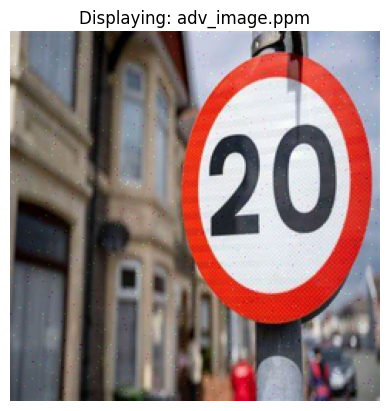

In [30]:
display_ppm_image(adv_image_path)

In [31]:
def predict_traffic_sign_all(img_input, model, class_mapping):
    """
    Accepts a tensor (rank 3 or 4), raw image bytes, or a file path.
    Prints the probability for each class and the predicted class.
    """
    # Get predictions
    prop = model.predict(img_input)
    print("Prediction shape:", prop.shape)

    # Assuming the output is of shape (1, num_classes)
    probabilities = prop[0]

    # Print probabilities for all classes
    for i, p in enumerate(probabilities):
        print(f"Class {i} ({class_mapping[i]}): {p:.4f}")

    # Determine the predicted class
    class_id = np.argmax(probabilities)
    print("Predicted class:", class_mapping[class_id])

    return class_id


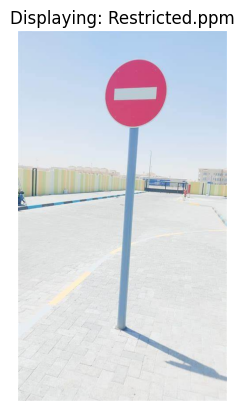

In [48]:
# Example usage:
convert_jfif_to_ppm("/No.jfif", "Restricted.ppm")
new_photo="Restricted.ppm"
display_ppm_image(new_photo)

In [49]:
new_image_path = "Restricted.ppm"
# Load and preprocess the image with the correct target size (240x240)
image = load_ppm_image(new_image_path, target_size=(240, 240))
# Call your prediction function with the image, model, and class mapping
predict_traffic_sign_all(image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0008
Class 8 (Speed limit 120): 0.0001
Class 9 (No passing): 0.3748
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0003
Class 13 (Yield): 0.0381
Class 14 (Stop): 0.0011
Class 15 (No vehicles): 0.0001
Class 16 (Vehicles over 3.5 tons prohibited): 0.0471
Class 17 (No entry): 0.0028
Class 18 (General caution): 0.0007
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0001
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.1361
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (T

np.int64(41)

In [53]:
# Example usage:
image_path = "Restricted.ppm"
model = tf.keras.models.load_model("TrafficSigns_EfficientNetB1.keras")  # Load your trained model
image_tensor = load_ppm_image(image_path, target_size=(240, 240))
true_label = predict_traffic_sign(image_tensor, model, GTSRB_CLASSES)
adv_image_tensor = simba_attack(image_tensor, true_label, model, num_iters=100, epsilon=50, print_every=10)
#
# # Optionally, save or visualize the adversarial image:
adv_image = adv_image_tensor.numpy()[0].astype(np.uint8)
adv_pil = Image.fromarray(adv_image)
adv_pil.save("Restriction_adv_image.ppm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Prediction shape: (1, 43)
Predicted class: End of no passing
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
Initial true class probability: 0.3940
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
Iteration 0: -epsilon -> pixel=(39,149,1), old_prob=0.393962, new_prob=0.393875, diff=-0.000087
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
Iteration 1: +epsilon -> pixel=(172,154,2), old_prob=0.393875, new_prob=0.392446, diff=-0.001429
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step
Iteration 2: +epsilon -> pixel=(98,213,1), old_prob=0.392446, new_prob=0.392410, diff=-0.000036
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step
Iteration 3: +epsilon -> pixel=(3,118,1), old_prob=0.392410, new_prob=0.392297, diff=-0.000113
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
Iteration 4: +epsilon -> pixel=(238,153,2), old_prob=0.392297, new_prob=0.392272, diff=-0.000026
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Iteration 5: +epsilon -> pixel=(179,26,1), old_prob=0.392272, new_prob=0.3

In [54]:
adverserial_image_path = "/content/Restriction_adv_image.ppm"
# Load and preprocess the image with the correct target size (240x240)
image = load_ppm_image(adverserial_image_path, target_size=(240, 240))
# Call your prediction function with the image, model, and class mapping
predict_traffic_sign_all(image, model, GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0009
Class 8 (Speed limit 120): 0.0001
Class 9 (No passing): 0.4114
Class 10 (No passing for vehicles over 3.5 tons): 0.0001
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0003
Class 13 (Yield): 0.0402
Class 14 (Stop): 0.0012
Class 15 (No vehicles): 0.0001
Class 16 (Vehicles over 3.5 tons prohibited): 0.0476
Class 17 (No entry): 0.0028
Class 18 (General caution): 0.0007
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0001
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.1447
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (T

np.int64(9)

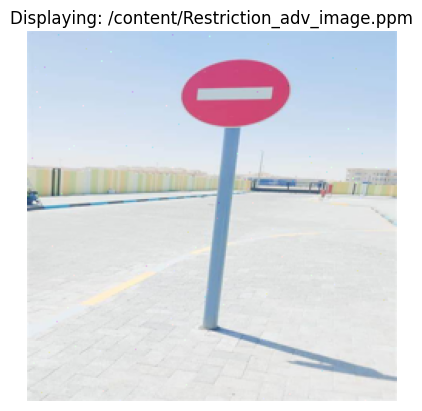

In [55]:
display_ppm_image(adverserial_image_path)